# Project: Loan Default Prediction V2

In [ ]:
# Core Libraries
import pandas as pd 
import numpy as np  

# Visualization
import matplotlib.pyplot as plt 
import seaborn as sns 

# Preprocessing 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation 
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# Model Saving
import joblib

# Explainable AI
import shap

d:\anaconda3\envs\ml-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Load Data

In [2]:
df = pd.read_csv('../data/raw/loan_approval_dataset.csv')
df.columns = df.columns.str.strip()  # Remove Extra Spaces from Column Names (ex:' loan_status') 

# 2. Data Exploration

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.shape

(4269, 13)

In [5]:
# Data information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [6]:
# Statistical Report
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [7]:
# Missing Values
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [8]:
# Duplicate values 
df.duplicated().sum()

np.int64(0)

In [9]:
list(df.columns)

['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [10]:
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

# 3. Visualization

### 3.1 - Target Distribution

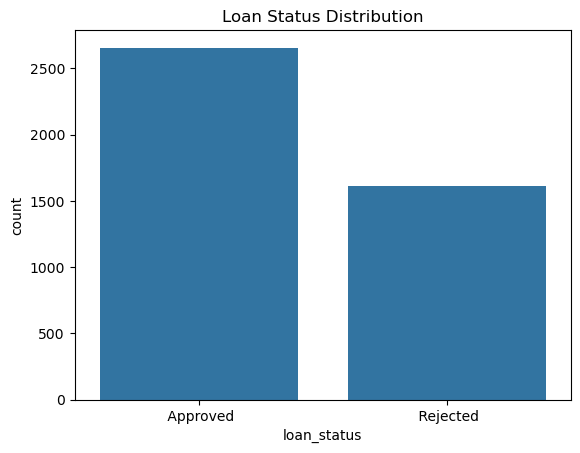

In [11]:
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.show()

### 3.2 - CIBIL Score Distribution

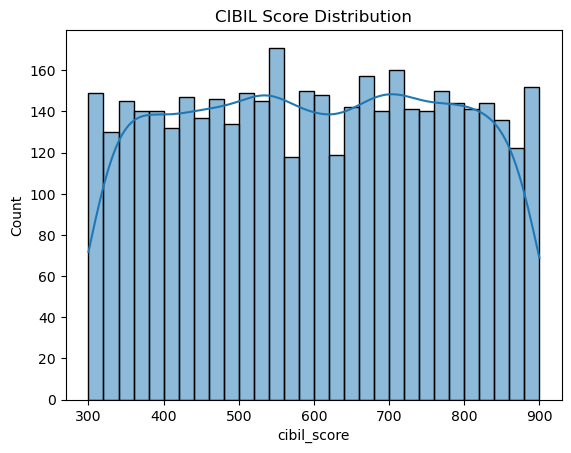

In [12]:
sns.histplot(df['cibil_score'], bins=30, kde=True)
plt.title('CIBIL Score Distribution')
plt.show()

### 3.3 - Income Distribution

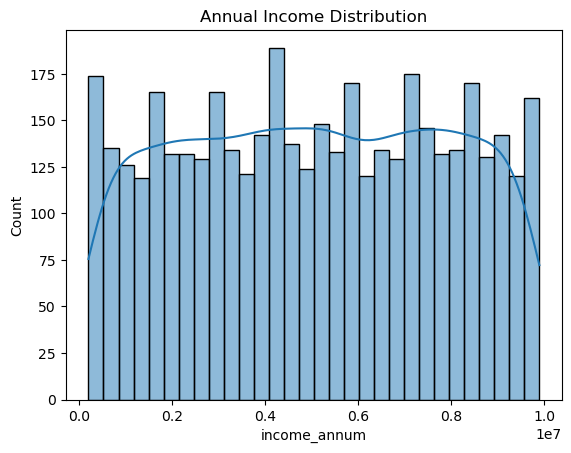

In [13]:
sns.histplot(df['income_annum'], bins=30, kde=True)
plt.title('Annual Income Distribution')
plt.show()

### 3.4 - CIBIL Score vs Loan Status

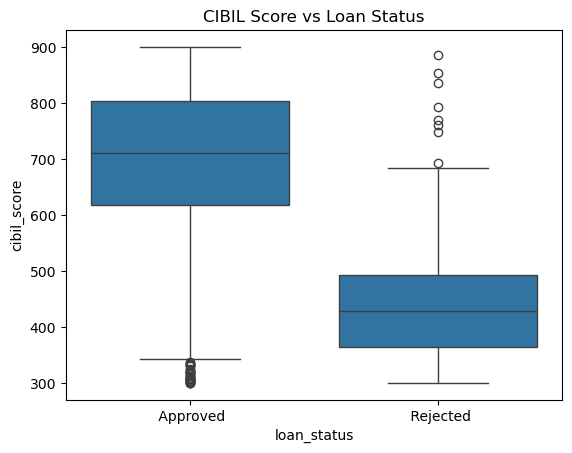

In [14]:
sns.boxplot(x='loan_status', y='cibil_score', data=df)
plt.title('CIBIL Score vs Loan Status')
plt.show()

### 3.5 - Income vs Loan Status

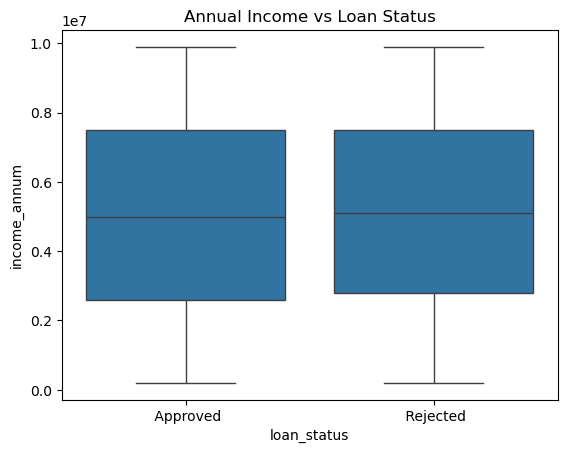

In [15]:
sns.boxplot(x='loan_status', y='income_annum', data=df)
plt.title('Annual Income vs Loan Status')
plt.show()

### 3.6 - Correlation Heatmap

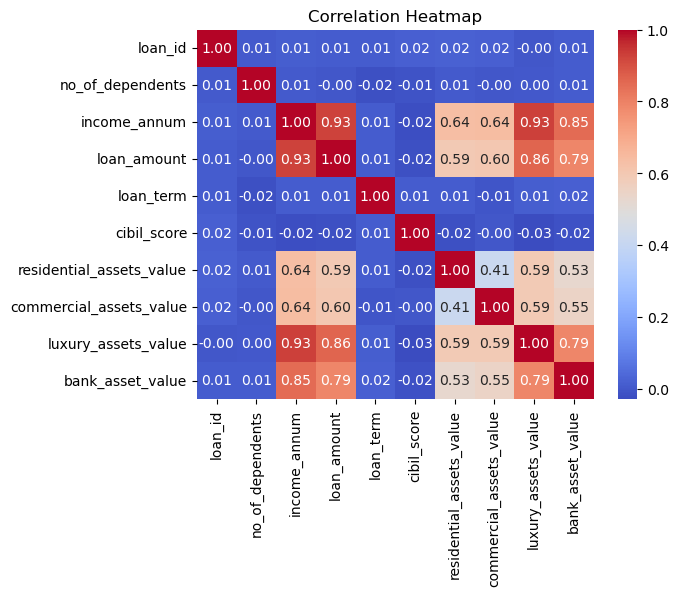

In [16]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 4. Data Preprocessing

### 4.1 - Drop unnecassary columns

In [17]:
df.drop(columns=['loan_id'], inplace=True)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


### 4.2 - Check Unique Value in Categorical columns

In [18]:
for col in df.columns: 
    if df[col].dtype == 'object': 
        print(f"{col}: {df[col].unique()}")   

education: [' Graduate' ' Not Graduate']
self_employed: [' No' ' Yes']
loan_status: [' Approved' ' Rejected']


### 4.3 - Strip spaces from all string values in dataset

In [19]:
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

### 4.4 - Verify strip operation

In [20]:
for col in df.columns: 
    if df[col].dtype == 'object': 
        print(f"{col}: {df[col].unique()}") 

education: ['Graduate' 'Not Graduate']
self_employed: ['No' 'Yes']
loan_status: ['Approved' 'Rejected']


### 4.5 Label Encoding

In [21]:
le = LabelEncoder()

for col in df.columns: 
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
        
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


### 4.6 - Feature & Target Split

In [22]:
X = df.drop('loan_status',axis=1)
y = df['loan_status']

### 4.7 - Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

In [24]:
print(X_train.shape, X_test.shape)

(3415, 11) (854, 11)


In [25]:
feature_cols = list(X_train.columns)
feature_cols

['no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value']

### 4.8 - Feature Scaling

In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 4.9 - Save Processed Data

In [27]:
pd.DataFrame(X_train, columns=feature_cols).to_csv('../data/processed/X_train.csv', index=False)
pd.DataFrame(X_test, columns=feature_cols).to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

# 5. Model Training

### 5.1 - Logistic Regression

In [28]:
lr = LogisticRegression(random_state=2, max_iter=1000)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [29]:
# Accuracy Score 
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")
print(f"Roc-Auc: {roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]):.4f}")

Logistic Regression Accuracy: 93.44%
Roc-Auc: 0.9812


In [30]:
# Classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       531
           1       0.92      0.90      0.91       323

    accuracy                           0.93       854
   macro avg       0.93      0.93      0.93       854
weighted avg       0.93      0.93      0.93       854



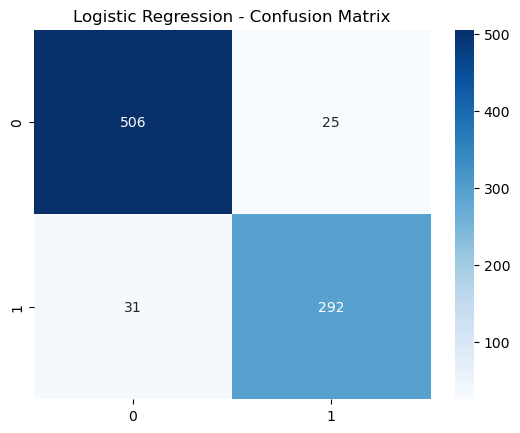

In [31]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

### 5.2 - Decision Tree

In [32]:
dt = DecisionTreeClassifier(random_state=2)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [33]:
# Accuracy Score 
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt) * 100:.2f}%")
print(f"Roc-Auc: {roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1]):.4f}")

Decision Tree Accuracy: 97.54%
Roc-Auc: 0.9772


In [34]:
# Classification report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       531
           1       0.95      0.98      0.97       323

    accuracy                           0.98       854
   macro avg       0.97      0.98      0.97       854
weighted avg       0.98      0.98      0.98       854



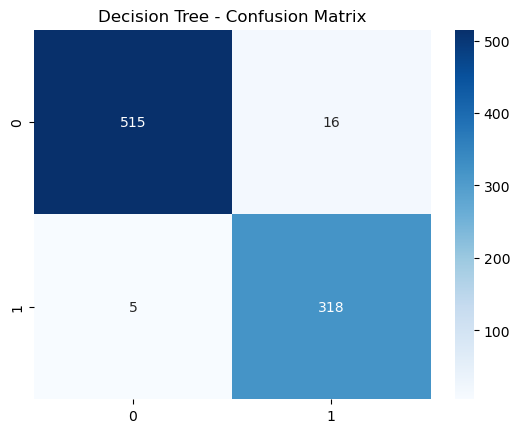

In [35]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

### 5.3 - Random Forest

In [36]:
rf = RandomForestClassifier(random_state=2, n_estimators=100)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [37]:
# Accuracy Score 
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"Roc-Auc: {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.4f}")

Random Forest Accuracy: 98.13%
Roc-Auc: 0.9992


In [38]:
# Classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       531
           1       0.98      0.98      0.98       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



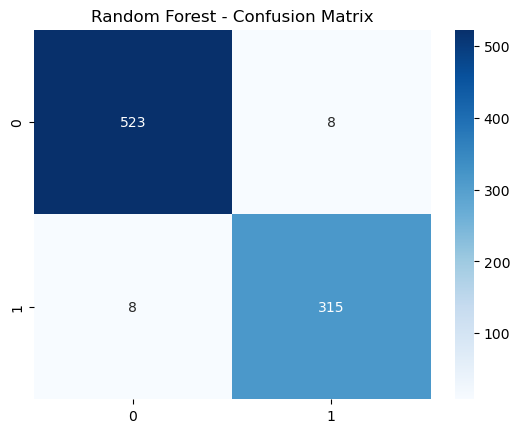

In [39]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()

### 5.4 - XGBoost

In [40]:
xgb = XGBClassifier(random_state=2)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [41]:
# Accuracy Score 
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(f"Roc-Auc: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]):.4f}")

XGBoost Accuracy: 99.06%
Roc-Auc: 0.9995


In [42]:
# Classification report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       531
           1       0.99      0.99      0.99       323

    accuracy                           0.99       854
   macro avg       0.99      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854



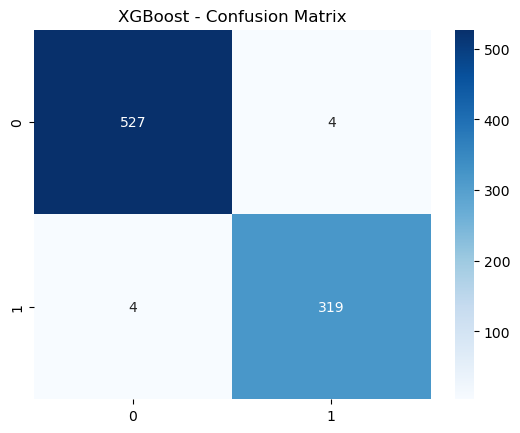

In [43]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost - Confusion Matrix')
plt.show()

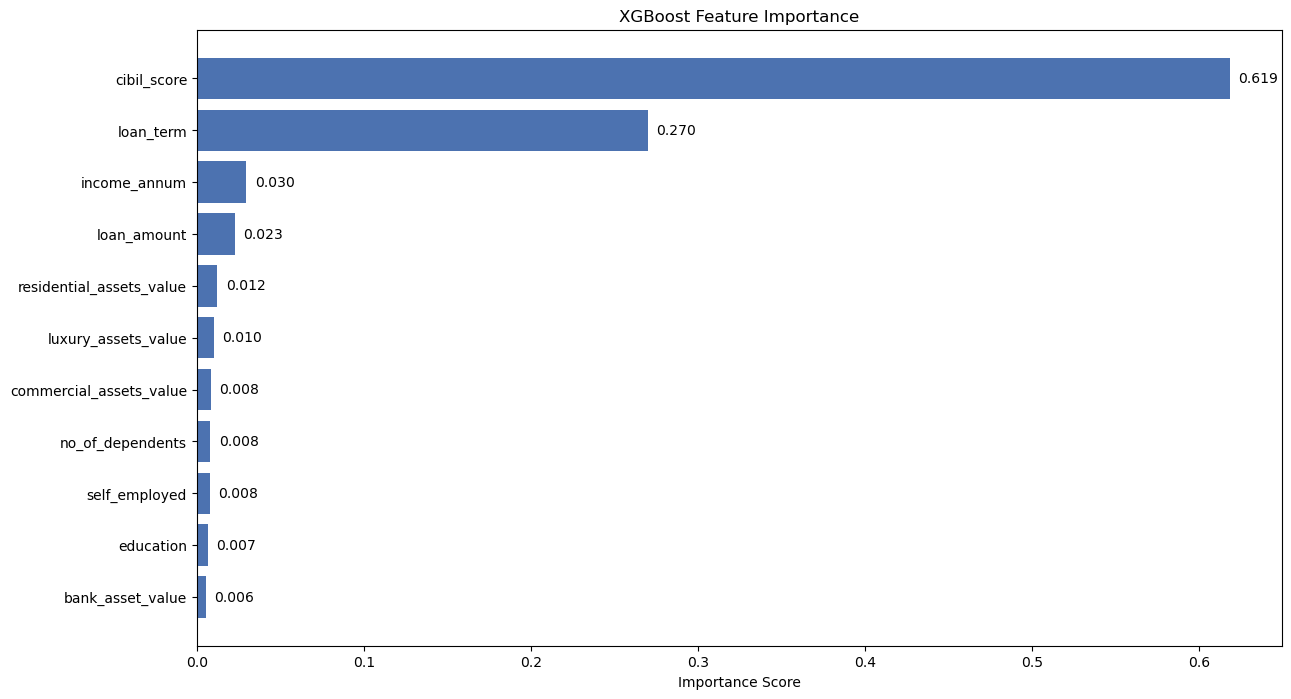

In [44]:
# Feature Importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(14, 8))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='#4C72B0')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center')

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.show()

### 5.5 - Model Comparision

In [45]:
# Model Comparision in Percentage
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_lr) * 100, 2),
        round(accuracy_score(y_test, y_pred_dt) * 100, 2),
        round(accuracy_score(y_test, y_pred_rf) * 100, 2), 
        round(accuracy_score(y_test, y_pred_xgb) * 100, 2)
    ]
}

pd.DataFrame(results).sort_values("Accuracy", ascending=False)

,Model,Accuracy
3,XGBoost,99.06
2,Random Forest,98.13
1,Decision Tree,97.54
0,Logistic Regression,93.44


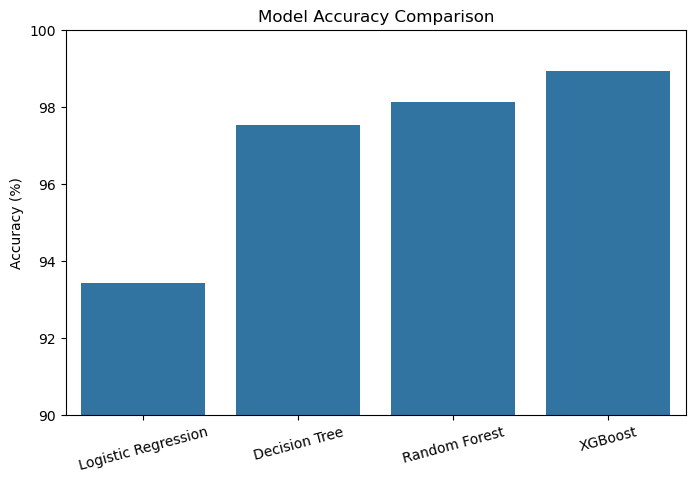

In [ ]:
# Model Comparison Bar Chart
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
accuracies = [93.44, 97.54, 98.13, 98.95]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(90, 100)
plt.xticks(rotation=15)
plt.show()

# 6. Cross Validation Check

In [47]:
# XGBoost CV 
cv_score = cross_val_score(xgb, X_train, y_train, cv=5, scoring='accuracy')

print(f"CV Score: {cv_score}")
print(f"Mean Accuracy: {cv_score.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_score.std() * 100:.2f}%") 

CV Score: [0.97071742 0.98096633 0.97803807 0.98389458 0.98389458]
Mean Accuracy: 97.95%
Standard Deviation: 0.49%


In [48]:
# Logistic Regression CV
cv_score = cross_val_score(lr, X_train, y_train, cv=5, scoring='accuracy')

print(f"CV Score: {cv_score}")
print(f"Mean Accuracy: {cv_score.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_score.std() * 100:.2f}%") 

CV Score: [0.91508053 0.90629575 0.90190337 0.89897511 0.92825769]
Mean Accuracy: 91.01%
Standard Deviation: 1.06%


In [49]:
# Random Forest CV
cv_score = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')

print(f"CV Score: {cv_score}")
print(f"Mean Accuracy: {cv_score.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_score.std() * 100:.2f}%") 

CV Score: [0.97071742 0.9795022  0.97803807 0.97510981 0.98682284]
Mean Accuracy: 97.80%
Standard Deviation: 0.53%


In [50]:
# Decision Tree CV
cv_score = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')

print(f"CV Score: {cv_score}")
print(f"Mean Accuracy: {cv_score.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_score.std() * 100:.2f}%") 

CV Score: [0.97510981 0.96486091 0.97218155 0.96339678 0.98389458]
Mean Accuracy: 97.19%
Standard Deviation: 0.74%


# 7. Model Save

## 7.1 - Saving XGBoost Model

In [51]:
joblib.dump(xgb, '../models/loan_default_model.pkl')

['../models/loan_default_model.pkl']

## 7.2 - Saving Scaler 

In [52]:
joblib.dump(scaler, '../models/scaler.pkl') 

['../models/scaler.pkl']

# Step 8 - Model Explainability (SHAP)

## Step 8.1 - Create SHAP Explainer

In [53]:
# Convert scaled test data back to DataFrame
X_test_df = pd.DataFrame(X_test, columns=feature_cols)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb)

# Generate SHAP values
shap_values = explainer.shap_values(X_test_df)

# Verify
print("SHAP Values Shape:", np.array(shap_values).shape)

SHAP Values Shape: (854, 11)


## Step 8.2 - SHAP Summary Plot

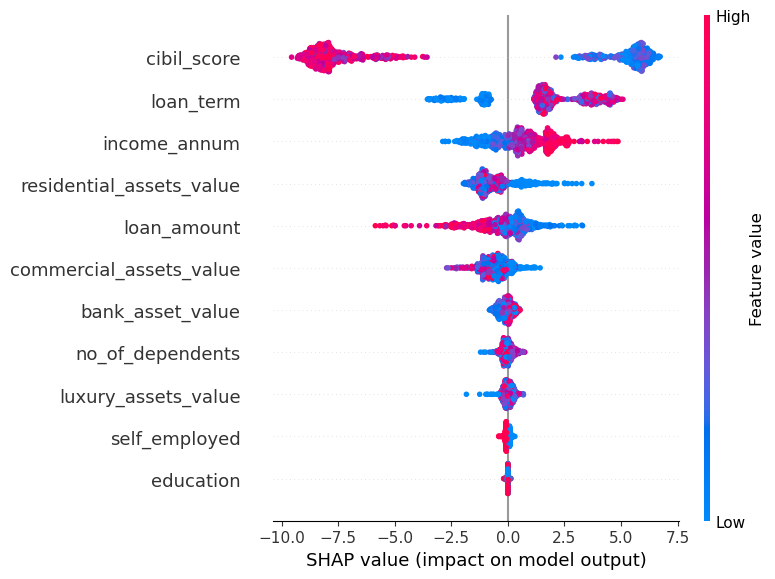

In [54]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=feature_cols
)

## Step 8.3 - Waterfall Plot for Single Applicant

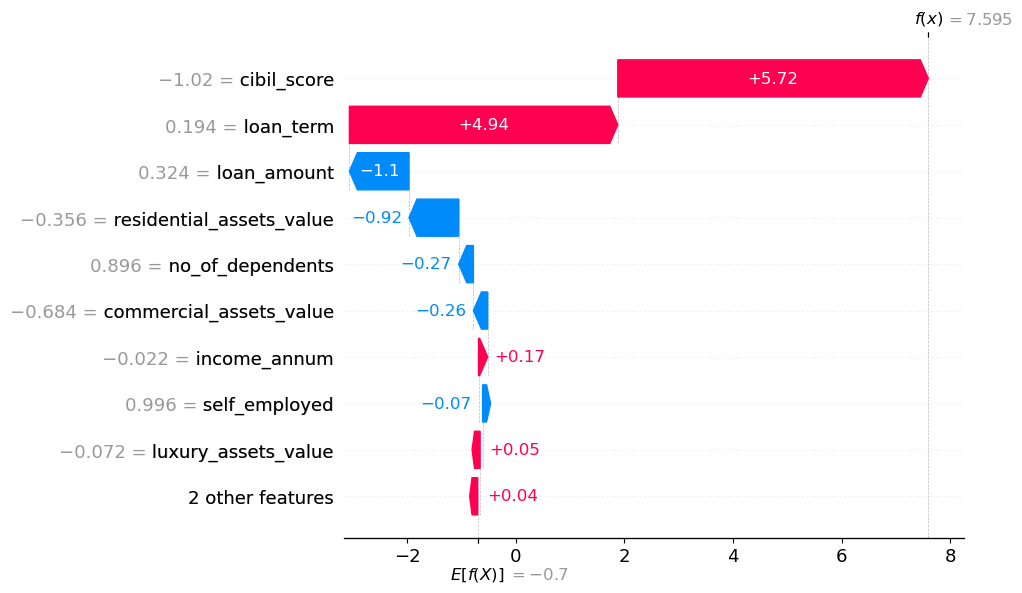

In [55]:
# Example: First Applicant

sample_idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[sample_idx].values,
        feature_names=feature_cols
    )
)

## Step 8.4 - Human Readable Explanation Function

In [56]:
def get_explanation(shap_row, feature_names, top_n=3):
    
    contributions = list(zip(feature_names, shap_row))
    
    positive = [c for c in contributions if c[1] > 0]
    negative = [c for c in contributions if c[1] < 0]
    
    positive = sorted(positive, key=lambda x: x[1], reverse=True)[:top_n]
    negative = sorted(negative, key=lambda x: x[1])[:top_n]
    
    return positive, negative

In [57]:
pos, neg = get_explanation(shap_values[0], feature_cols)
print("Positive:", pos)
print("Negative:", neg)

Positive: [('cibil_score', np.float32(5.715713)), ('loan_term', np.float32(4.9406133)), ('income_annum', np.float32(0.16777807))]
Negative: [('loan_amount', np.float32(-1.0972004)), ('residential_assets_value', np.float32(-0.9154988)), ('no_of_dependents', np.float32(-0.2704641))]


## Step 8.5 - Convert to Human Readable Text

In [58]:
feature_labels = {
    'no_of_dependents': 'number of dependents',
    'education': 'education level',
    'self_employed': 'self-employment status',
    'income_annum': 'annual income',
    'loan_amount': 'loan amount requested',
    'loan_term': 'loan term',
    'cibil_score': 'CIBIL score',
    'residential_assets_value': 'residential assets value',
    'commercial_assets_value': 'commercial assets value',
    'luxury_assets_value': 'luxury assets value',
    'bank_asset_value': 'bank assets value'
}

def explain_in_words(positive, negative):
    pos_text = [f"Your {feature_labels[f]} positively supported the decision" for f, v in positive]
    neg_text = [f"Your {feature_labels[f]} negatively impacted the decision" for f, v in negative]
    return pos_text, neg_text

In [59]:
pos_text, neg_text = explain_in_words(pos, neg)
print("Why Approved/Rejected:")
for t in pos_text:
    print("✅", t)
for t in neg_text:
    print("❌", t)

Why Approved/Rejected:
✅ Your CIBIL score positively supported the decision
✅ Your loan term positively supported the decision
✅ Your annual income positively supported the decision
❌ Your loan amount requested negatively impacted the decision
❌ Your residential assets value negatively impacted the decision
❌ Your number of dependents negatively impacted the decision


## Step 8.6 - Generate Recommendations

In [60]:
recommendation_map = {
    'cibil_score': 'Improving your CIBIL score could significantly increase your approval chances.',
    'loan_amount': 'Consider requesting a lower loan amount relative to your income and assets.',
    'income_annum': 'A higher annual income would strengthen your application.',
    'loan_term': 'Adjusting your loan term may improve your approval likelihood.',
    'no_of_dependents': 'A lower number of dependents relative to your income works in your favor.',
    'residential_assets_value': 'Having stronger residential assets could improve your profile.',
    'commercial_assets_value': 'Stronger commercial assets would support your application.',
    'luxury_assets_value': 'Your luxury assets value is currently working against your application.',
    'bank_asset_value': 'Higher bank assets would strengthen your financial profile.',
    'education': 'Your education status is a factor in this decision.',
    'self_employed': 'Your employment type is a factor in this decision.'
}

def generate_recommendations(negative):
    return [recommendation_map[f] for f, v in negative]

In [61]:
recommendations = generate_recommendations(neg)
print("Suggestions to improve approval chances:")
for r in recommendations:
    print("💡", r)

Suggestions to improve approval chances:
💡 Consider requesting a lower loan amount relative to your income and assets.
💡 Having stronger residential assets could improve your profile.
💡 A lower number of dependents relative to your income works in your favor.


## Conclusion

- 4 models trained: Logistic Regression, Decision Tree, Random Forest, XGBoost
- XGBoost best performer — 98.95% accuracy, 0.9996 ROC-AUC
- 5-fold cross validation confirmed model is stable — 97.95% mean CV accuracy
- CIBIL Score most influential feature in loan approval decision
- Model deployed via Streamlit for real-time predictions
- Integrated SHAP for model explainability — shows top reasons behind each prediction